<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/BTC%2BETH_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. DOWNLOAD AND LOAD DATA
Using Colab cache for faster access to the 'high-frequency-crypto-limit-order-book-data' dataset.
Dataset path: /kaggle/input/high-frequency-crypto-limit-order-book-data
BTC shape: (100000, 156)
ETH shape: (100000, 156)

2. TIME ALIGNMENT
BTC time range: 2021-04-07 11:32:42+00:00 → 2021-04-08 15:19:54+00:00
ETH time range: 2021-04-07 11:32:50+00:00 → 2021-04-08 15:19:46+00:00
After merge: (99972, 160)  (99,972 rows retained)

3. FEATURE ENGINEERING
Shape after dropna: (99902, 178)
Label distribution:
label
-1    21562
 0    56846
 1    21494

LOB features   : 60
Market features: 15

4. PCA
LOB features : 60
PCA components retained (90% variance): 30
Train PCA shape: (79921, 30)
Test  PCA shape: (19981, 30)

5. PCA DIAGNOSTICS


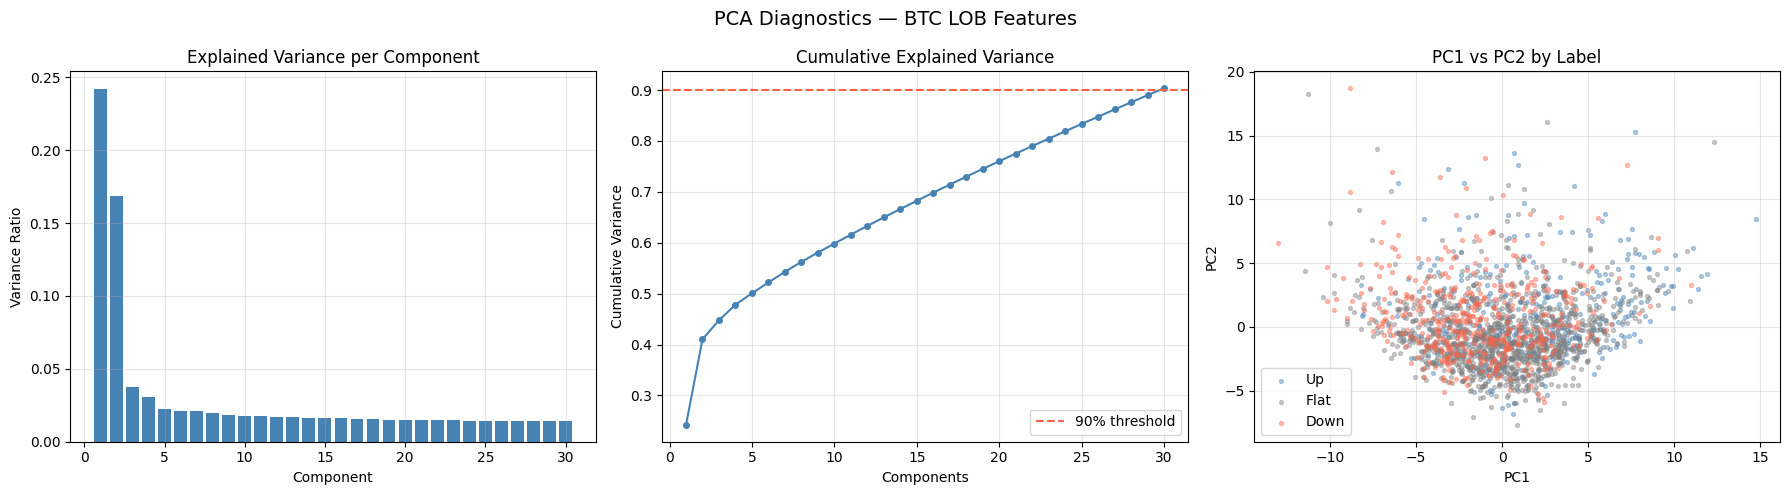


6 & 7. EXPORT DATASETS FOR ABLATION TO GOOGLE DRIVE
Saved -> /content/drive/MyDrive/lob_full.csv | Shape: (99902, 48)
Saved -> /content/drive/MyDrive/lob_no_pca.csv | Shape: (99902, 78)
Saved -> /content/drive/MyDrive/lob_no_market.csv | Shape: (99902, 33)

Data preparation complete! Ready for PyTorch ablation studies.


In [4]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==========================================
# 1. Download and Load Data
# ==========================================
print("=" * 50)
print("1. DOWNLOAD AND LOAD DATA")
print("=" * 50)

dataset_path = kagglehub.dataset_download("martinsn/high-frequency-crypto-limit-order-book-data")
print(f"Dataset path: {dataset_path}")

btc = pd.read_csv(os.path.join(dataset_path, 'BTC_1sec.csv'), nrows=100000)
eth = pd.read_csv(os.path.join(dataset_path, 'ETH_1sec.csv'), nrows=100000)
print(f"BTC shape: {btc.shape}")
print(f"ETH shape: {eth.shape}")


# ==========================================
# 2. Time Alignment
# ==========================================
print("\n" + "=" * 50)
print("2. TIME ALIGNMENT")
print("=" * 50)

# Parse timestamps
btc['system_time'] = pd.to_datetime(btc['system_time'], utc=True)
eth['system_time'] = pd.to_datetime(eth['system_time'], utc=True)

# Floor to second to handle microsecond mismatch between BTC and ETH feeds
btc['time_key'] = btc['system_time'].dt.floor('s')
eth['time_key'] = eth['system_time'].dt.floor('s')

print(f"BTC time range: {btc['time_key'].min()} → {btc['time_key'].max()}")
print(f"ETH time range: {eth['time_key'].min()} → {eth['time_key'].max()}")

# Slim down ETH to only the columns needed for market features
eth_slim = eth[['time_key', 'midpoint', 'spread',
                 'bids_notional_0', 'asks_notional_0']].copy()
eth_slim = eth_slim.rename(columns={
    'midpoint':        'eth_midpoint',
    'spread':          'eth_spread',
    'bids_notional_0': 'eth_bids_notional_0',
    'asks_notional_0': 'eth_asks_notional_0',
})

# Inner join — only keep rows where both assets have data at the same second
df = pd.merge(btc, eth_slim, on='time_key', how='inner')
df = df.drop(columns=['time_key']).reset_index(drop=True)
print(f"After merge: {df.shape}  ({len(df):,} rows retained)")


# ==========================================
# 3. Feature Engineering
# ==========================================
print("\n" + "=" * 50)
print("3. FEATURE ENGINEERING")
print("=" * 50)

window_short = 10   # 10-second rolling window
window_long  = 60   # 60-second rolling window

# ── BTC mid price ──────────────────────────────────────────
df['mid_price']   = df['midpoint']
df['log_return']  = np.log(df['mid_price'] / df['mid_price'].shift(1))

# ── BTC market state features ──────────────────────────────
df['btc_oimb_1'] = (
    (df['bids_notional_0'] - df['asks_notional_0']) /
    (df['bids_notional_0'] + df['asks_notional_0'] + 1e-8)
)
df['btc_volatility_10s'] = df['log_return'].rolling(window_short).std()
df['btc_volatility_60s'] = df['log_return'].rolling(window_long).std()
df['btc_momentum_10s']   = df['log_return'].rolling(window_short).sum()
df['btc_momentum_60s']   = df['log_return'].rolling(window_long).sum()

# ── ETH cross-asset features ───────────────────────────────
df['eth_log_return'] = np.log(df['eth_midpoint'] / df['eth_midpoint'].shift(1))
df['eth_oimb_1'] = (
    (df['eth_bids_notional_0'] - df['eth_asks_notional_0']) /
    (df['eth_bids_notional_0'] + df['eth_asks_notional_0'] + 1e-8)
)
df['eth_volatility_10s'] = df['eth_log_return'].rolling(window_short).std()
df['eth_volatility_60s'] = df['eth_log_return'].rolling(window_long).std()
df['eth_momentum_10s']   = df['eth_log_return'].rolling(window_short).sum()
df['eth_momentum_60s']   = df['eth_log_return'].rolling(window_long).sum()

# ── BTC-ETH cross features ─────────────────────────────────
df['btc_eth_momentum_diff_10s'] = df['btc_momentum_10s'] - df['eth_momentum_10s']
df['btc_eth_momentum_diff_60s'] = df['btc_momentum_60s'] - df['eth_momentum_60s']
df['btc_eth_vol_ratio_10s']     = (
    df['btc_volatility_10s'] / (df['eth_volatility_10s'] + 1e-8)
)

# ── Prediction labels (BTC price direction, 10s ahead) ─────
prediction_horizon = 10
label_threshold    = 0.00015

df['future_return'] = (
    (df['mid_price'].shift(-prediction_horizon) - df['mid_price'])
    / df['mid_price']
)
df['label'] = np.select(
    [df['future_return'] >  label_threshold,
     df['future_return'] < -label_threshold],
    [1, -1],
    default=0
)

# Drop NaN rows generated by rolling windows and forward shift
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape after dropna: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts().sort_index().to_string()}")

# Feature column lists (used downstream)
lob_features = []
for i in range(15):
    lob_features.extend([
        f'bids_distance_{i}', f'asks_distance_{i}',
        f'bids_notional_{i}', f'asks_notional_{i}'
    ])

market_state_cols = [
    # BTC
    'spread',            'btc_oimb_1',
    'btc_volatility_10s','btc_volatility_60s',
    'btc_momentum_10s',  'btc_momentum_60s',
    # ETH
    'eth_spread',        'eth_oimb_1',
    'eth_volatility_10s','eth_volatility_60s',
    'eth_momentum_10s',  'eth_momentum_60s',
    # BTC-ETH divergence
    'btc_eth_momentum_diff_10s',
    'btc_eth_momentum_diff_60s',
    'btc_eth_vol_ratio_10s',
]

print(f"\nLOB features   : {len(lob_features)}")
print(f"Market features: {len(market_state_cols)}")


# ==========================================
# 4. PCA on BTC LOB Features
# ==========================================
print("\n" + "=" * 50)
print("4. PCA")
print("=" * 50)

X_lob     = df[lob_features].values
split_idx = int(len(df) * 0.8)        # chronological 80/20 split

X_train_lob = X_lob[:split_idx]
X_test_lob  = X_lob[split_idx:]

# Standardise — fit on train only to prevent data leakage
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lob)
X_test_scaled  = scaler.transform(X_test_lob)

# Retain components explaining 90% of variance
pca         = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"LOB features : {len(lob_features)}")
print(f"PCA components retained (90% variance): {pca.n_components_}")
print(f"Train PCA shape: {X_train_pca.shape}")
print(f"Test  PCA shape: {X_test_pca.shape}")


# ==========================================
# 5. PCA Diagnostic Plots
# ==========================================
print("\n" + "=" * 50)
print("5. PCA DIAGNOSTICS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA Diagnostics — BTC LOB Features", fontsize=14)

# ── Scree plot ─────────────────────────────────────────────
axes[0].bar(range(1, pca.n_components_ + 1),
            pca.explained_variance_ratio_, color='steelblue')
axes[0].set_title("Explained Variance per Component")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Variance Ratio")
axes[0].grid(alpha=0.3)

# ── Cumulative variance ────────────────────────────────────
cum = pca.explained_variance_ratio_.cumsum()
axes[1].plot(range(1, pca.n_components_ + 1), cum, color='steelblue', marker='o', ms=4)
axes[1].axhline(0.90, color='tomato', linestyle='--', label='90% threshold')
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Components"); axes[1].set_ylabel("Cumulative Variance")
axes[1].legend(); axes[1].grid(alpha=0.3)

# ── PC1 vs PC2 scatter by label ────────────────────────────
idx      = np.random.choice(len(X_train_pca), min(2000, len(X_train_pca)), replace=False)
y_train  = df['label'].iloc[:split_idx]
colors   = {1: 'steelblue', 0: 'gray', -1: 'tomato'}
labels_n = {1: 'Up', 0: 'Flat', -1: 'Down'}
for lbl, color in colors.items():
    mask = y_train.iloc[idx] == lbl
    axes[2].scatter(
        X_train_pca[idx][mask, 0],
        X_train_pca[idx][mask, 1],
        c=color, alpha=0.4, s=8, label=labels_n[lbl]
    )
axes[2].set_title("PC1 vs PC2 by Label")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================
# 6 & 7. Final Dataset Assembly & Export
# ==========================================
print("\n" + "=" * 50)
print("6 & 7. EXPORT DATASETS FOR ABLATION TO GOOGLE DRIVE")
print("=" * 50)

# Define Google Drive save path
save_path = "/content/drive/MyDrive/"

pca_cols = [f'pca_{i+1}' for i in range(pca.n_components_)]
pca_df   = pd.DataFrame(np.vstack((X_train_pca, X_test_pca)), columns=pca_cols, index=df.index)

# Common columns: label, future actual return (crucial for backtesting!), and train/test split flag
common_cols = pd.DataFrame({
    'label': df['label'].values,
    'future_return': df['future_return'].values,
    'split': ['train'] * split_idx + ['test'] * (len(df) - split_idx)
}, index=df.index)

# ── Dataset A: Full (PCA + Market Features) ──
df_full = pd.concat([pca_df, df[market_state_cols], common_cols], axis=1)
df_full.to_csv(save_path + "lob_full.csv", index=False)
print(f"Saved -> {save_path}lob_full.csv | Shape: {df_full.shape}")

# ── Dataset B: No PCA (Raw LOB + Market Features) ──
df_no_pca = pd.concat([df[lob_features], df[market_state_cols], common_cols], axis=1)
df_no_pca.to_csv(save_path + "lob_no_pca.csv", index=False)
print(f"Saved -> {save_path}lob_no_pca.csv | Shape: {df_no_pca.shape}")

# ── Dataset C: No Market Features (PCA LOB Only) ──
df_no_market = pd.concat([pca_df, common_cols], axis=1)
df_no_market.to_csv(save_path + "lob_no_market.csv", index=False)
print(f"Saved -> {save_path}lob_no_market.csv | Shape: {df_no_market.shape}")

print("\nData preparation complete! Ready for PyTorch ablation studies.")

